In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [58]:
df =  pd.read_csv('https://raw.githubusercontent.com/HumayDS/Digital-Data-Analytics-E-15-24/refs/heads/main/Ecommerce_Product_Sales.csv')

In [59]:
#“This dataset represents product sales data from an e-commerce company.
#Each row corresponds to one product and contains information about sales performance, pricing, customer satisfaction, and seller performance.”
# Rating - Customer rating score
#Return rate - Percentage of returned products
#Seller name - Seller responsible for the product
df.head()

,Product_ID,Product_Name,Category,Price,Units_Sold,Revenue,Rating,Return_Rate,Seller_Name
0,Product_1,Max Product_1,Toys,358.65,983,352552.95,3.63,0.16,Seller_B
1,Product_2,Pro Product_2,Home & Kitchen,248.00,79,19592.00,1.23,0.20,Seller_E
2,Product_3,Eco Product_3,Automotive,148.12,206,30512.72,2.09,0.05,Seller_D
3,Product_4,Super Product_4,Electronics,15.76,585,9219.60,3.69,0.05,Seller_D
4,Product_5,Ultra Product_5,Home & Kitchen,20.84,401,8356.84,2.01,0.15,Seller_B


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_ID    500 non-null    object 
 1   Product_Name  500 non-null    object 
 2   Category      500 non-null    object 
 3   Price         500 non-null    float64
 4   Units_Sold    500 non-null    int64  
 5   Revenue       500 non-null    float64
 6   Rating        500 non-null    float64
 7   Return_Rate   500 non-null    float64
 8   Seller_Name   500 non-null    object 
dtypes: float64(4), int64(1), object(4)
memory usage: 35.3+ KB


In [61]:
df.shape

(500, 9)

In [62]:
df.describe()


,Price,Units_Sold,Revenue,Rating,Return_Rate
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,252.104420,486.214000,120652.923440,2.935440,0.155800
std,139.327685,281.566218,104922.102724,1.166275,0.086339
min,5.170000,6.000000,235.410000,1.000000,0.000000
25%,140.077500,241.500000,32071.540000,1.927500,0.080000
50%,255.570000,489.000000,87838.445000,2.920000,0.160000
75%,366.125000,720.250000,191337.495000,3.940000,0.230000
max,499.970000,995.000000,445898.460000,5.000000,0.300000


In [63]:
df.isnull().sum()

,0
Product_ID,0
Product_Name,0
Category,0
Price,0
Units_Sold,0
Revenue,0
Rating,0
Return_Rate,0
Seller_Name,0


In [64]:
df.duplicated().sum()

np.int64(0)

#Category analysis

In [65]:
df['Category'].value_counts()

,count
Category,
Automotive,70
Electronics,67
Home & Kitchen,62
Toys,61
Books,61
Beauty,60
Sports,60
Clothing,59


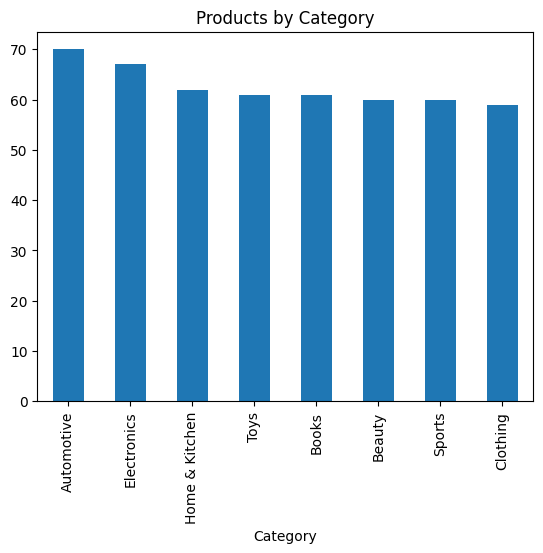

In [66]:
import matplotlib.pyplot as plt

df['Category'].value_counts().plot(kind='bar')
plt.title("Products by Category")
plt.show()

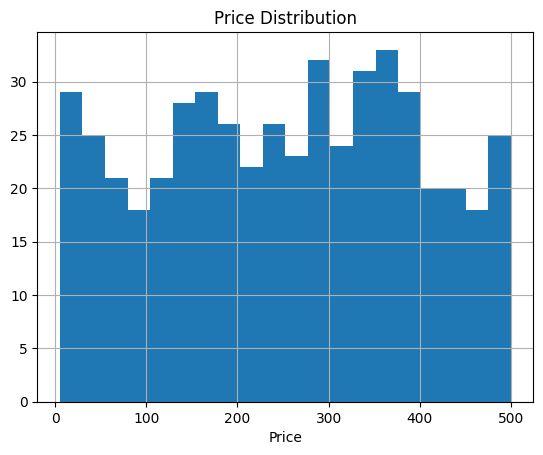

In [67]:
#Price distribution
# Are there many premium products, or are most products low-priced?
df['Price'].hist(bins=20)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.show()

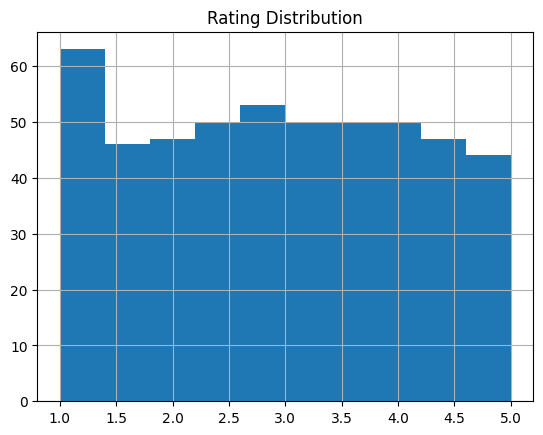

In [68]:
df['Rating'].hist()
plt.title("Rating Distribution")
plt.show()

#Revenue analysis

In [69]:
top_products = df.sort_values(by='Revenue', ascending=False)

top_products[['Product_Name', 'Revenue']].head(10)

,Product_Name,Revenue
452,Eco Product_453,445898.46
281,Super Product_282,434473.93
214,Max Product_215,429472.32
198,Ultra Product_199,428431.60
128,Eco Product_129,412502.09
75,Max Product_76,405499.57
497,Max Product_498,401667.04
95,Eco Product_96,399985.78
257,Max Product_258,398129.32
294,Super Product_295,395633.48


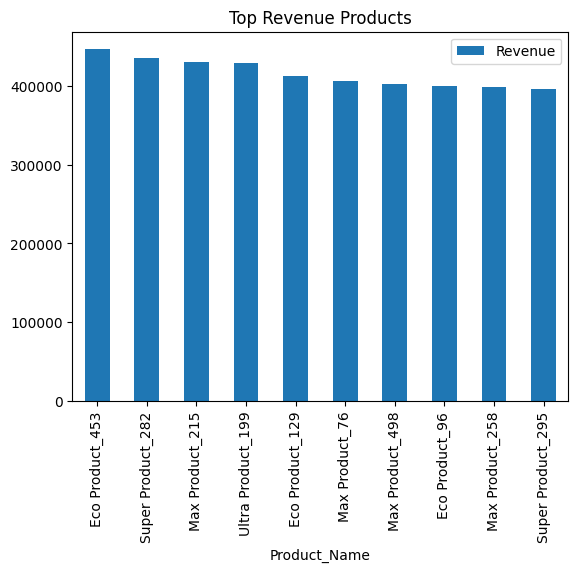

In [70]:
top_products.head(10).plot(
    x='Product_Name',
    y='Revenue',
    kind='bar'
)

plt.title("Top Revenue Products")
plt.show()

#Category performance

In [71]:
df.groupby('Category')['Revenue'].mean().sort_values(ascending=False)

,Revenue
Category,
Toys,141803.519672
Beauty,134343.402167
Electronics,125954.451940
Books,124440.164262
Clothing,122455.204915
Automotive,117106.620714
Home & Kitchen,110322.456774
Sports,88728.862167


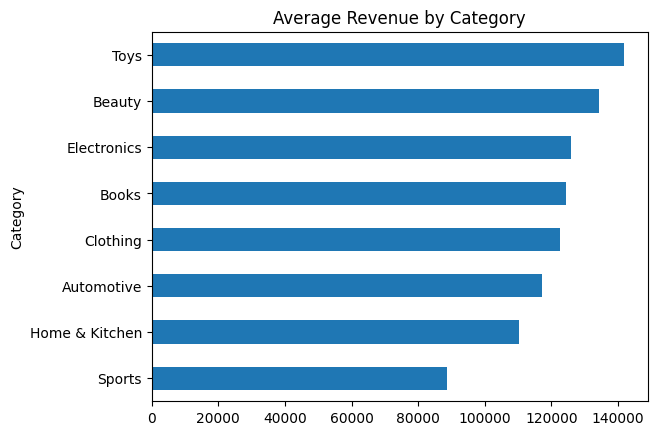

In [72]:
df.groupby('Category')['Revenue'].mean().sort_values().plot(kind='barh')

plt.title("Average Revenue by Category")
plt.show()

# Seller analysis

In [73]:
df.groupby('Seller_Name')['Revenue'].sum().sort_values(ascending=False)

,Revenue
Seller_Name,
Seller_A,13971122.88
Seller_C,11797190.33
Seller_D,11768743.10
Seller_B,11672415.74
Seller_E,11116989.67


In [84]:
#Seller performance
seller_perf = df.groupby('Seller_Name').agg({
    'Revenue':'sum',
    'Units_Sold':'sum',
    'Rating':'mean'
})

seller_perf

,Revenue,Units_Sold,Rating
Seller_Name,,,
Seller_A,13971122.88,54929,2.926786
Seller_B,11672415.74,45418,3.071429
Seller_C,11797190.33,47206,2.863431
Seller_D,11768743.10,48831,2.899192
Seller_E,11116989.67,46723,2.919438


#Correlation Analysis

In [75]:
numeric_cols = df.select_dtypes(include='number')

numeric_cols.corr()

,Price,Units_Sold,Revenue,Rating,Return_Rate
Price,1.000000,-0.049137,0.626172,0.014584,0.046875
Units_Sold,-0.049137,1.000000,0.658000,0.008402,-0.027577
Revenue,0.626172,0.658000,1.000000,-0.000505,0.016692
Rating,0.014584,0.008402,-0.000505,1.000000,0.079532
Return_Rate,0.046875,-0.027577,0.016692,0.079532,1.000000


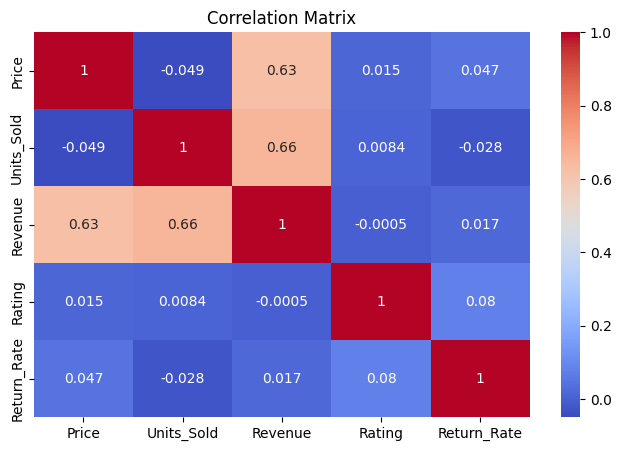

In [76]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

#Scatterplot

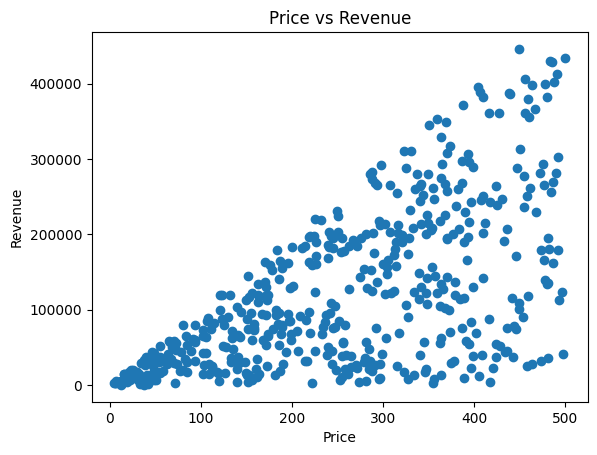

In [77]:
plt.scatter(df['Price'], df['Revenue'])

plt.xlabel("Price")
plt.ylabel("Revenue")
plt.title("Price vs Revenue")

plt.show()

# Rating vs Units sold

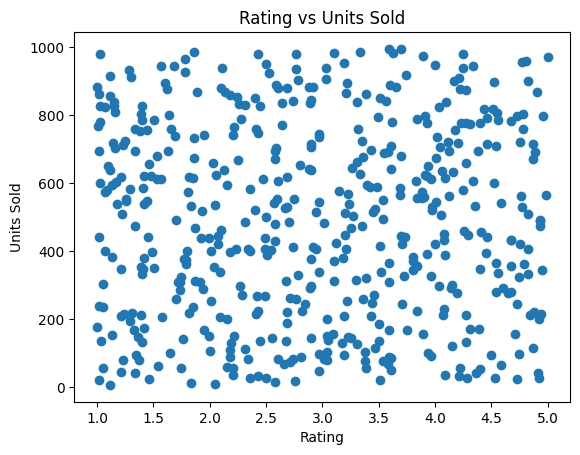

In [78]:
#Better rating → more sales?
plt.scatter(df['Rating'], df['Units_Sold'])

plt.xlabel("Rating")
plt.ylabel("Units Sold")
plt.title("Rating vs Units Sold")

plt.show()

# Return Analysis

In [79]:
df.sort_values(by='Return_Rate', ascending=False)[
    ['Product_Name','Category','Return_Rate']
].head(10)

,Product_Name,Category,Return_Rate
87,Pro Product_88,Toys,0.3
396,Super Product_397,Electronics,0.3
407,Super Product_408,Automotive,0.3
134,Ultra Product_135,Sports,0.3
357,Super Product_358,Electronics,0.3
341,Max Product_342,Sports,0.3
372,Max Product_373,Beauty,0.3
117,Pro Product_118,Sports,0.3
315,Pro Product_316,Automotive,0.3
91,Max Product_92,Electronics,0.3


#KPI section

In [80]:
total_revenue = df['Revenue'].sum()

avg_rating = df['Rating'].mean()

total_units = df['Units_Sold'].sum()

avg_return = df['Return_Rate'].mean()

In [81]:
print("Total Revenue:", total_revenue)
print("Average Rating:", avg_rating)
print("Total Units Sold:", total_units)
print("Average Return Rate:", avg_return)

Total Revenue: 60326461.72
Average Rating: 2.9354400000000003
Total Units Sold: 243107
Average Return Rate: 0.15580000000000002


# Revenue segments

In [82]:
df['Revenue_Segment'] = pd.qcut(
    df['Revenue'],
    q=3,
    labels=['Low','Medium','High']
)

In [83]:
df.groupby('Revenue_Segment')[[
    'Rating',
    'Return_Rate',
    'Units_Sold'
]].mean()

/tmp/ipykernel_856/3221117282.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Revenue_Segment')[[


,Rating,Return_Rate,Units_Sold
Revenue_Segment,,,
Low,2.898802,0.147066,276.862275
Medium,2.981566,0.160361,466.042169
High,2.926228,0.160000,715.616766
